In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn import metrics

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#dataset

In [2]:
df = pd.read_csv('/content/faang_stock_prices.csv')
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


In [19]:
df.shape

(14964, 19)

In [4]:
df.describe()

,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
count,14964.000000,14964.000000,14964.000000,14964.000000,1.496400e+04,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000
mean,147.969959,149.643762,146.256716,147.999839,1.186247e+08,147.631588,146.746646,147.314335,146.428158,55.686976,0.886176,0.888239,156.048174,137.572513,0.001335,0.018537,148.126287
std,132.599874,134.001750,131.065146,132.547711,1.889461e+08,132.261571,131.557653,131.956650,131.170115,16.597436,4.177106,3.932864,139.825874,123.751294,0.022069,0.012431,132.632577
min,0.762756,0.777392,0.746413,0.767738,4.726100e+06,0.710800,0.683503,0.704268,0.691066,3.180003,-33.155902,-30.727270,0.780719,0.569458,-0.263901,0.001171,0.767738
25%,50.094322,50.468777,49.669161,50.083026,2.428050e+07,49.906533,49.334041,49.600781,49.146090,43.754097,-0.331123,-0.283075,51.982837,47.077112,-0.008375,0.010449,50.149251
50%,123.841343,125.102966,122.262753,123.922924,4.432600e+07,123.301276,122.667958,123.067546,122.222704,56.381405,0.507975,0.491224,131.496224,114.337861,0.001286,0.015466,124.013718
75%,189.299623,191.429458,186.986899,189.079613,1.057329e+08,188.811102,187.325549,187.740894,186.739774,67.819077,2.160937,2.068120,199.721259,176.264492,0.011626,0.022748,189.254452
max,789.972167,795.064526,779.657506,788.823792,3.692928e+09,775.982954,762.484980,766.193137,757.613109,100.000000,29.441884,26.790650,813.954233,734.580075,0.298067,0.120255,788.823792


In [11]:
df.info()
df['Date'] = pd.to_datetime(df['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  object 
 1   Ticker           14964 non-null  object 
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Volatility_7

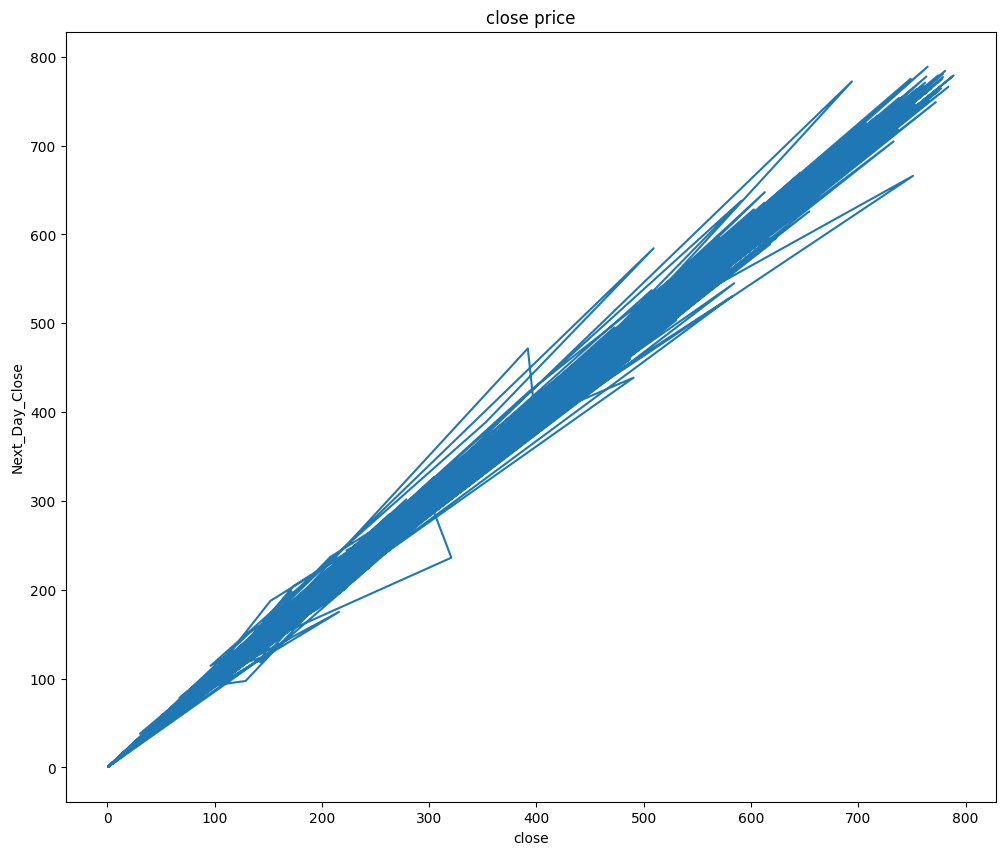

In [21]:
#data analysis
plt.figure(figsize=(12,10))
plt.plot(df["Close"], df["Next_Day_Close"])
plt.title("close price")
plt.xlabel("close")
plt.ylabel("Next_Day_Close")
plt.show()

In [13]:
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239


In [20]:
df[df["Close"] == df["Next_Day_Close"]].shape

(34, 19)

In [22]:
df.isnull().sum()

,0
Date,0
Ticker,0
Open,0
High,0
Low,0
Close,0
Volume,0
SMA_7,0
SMA_21,0
EMA_12,0


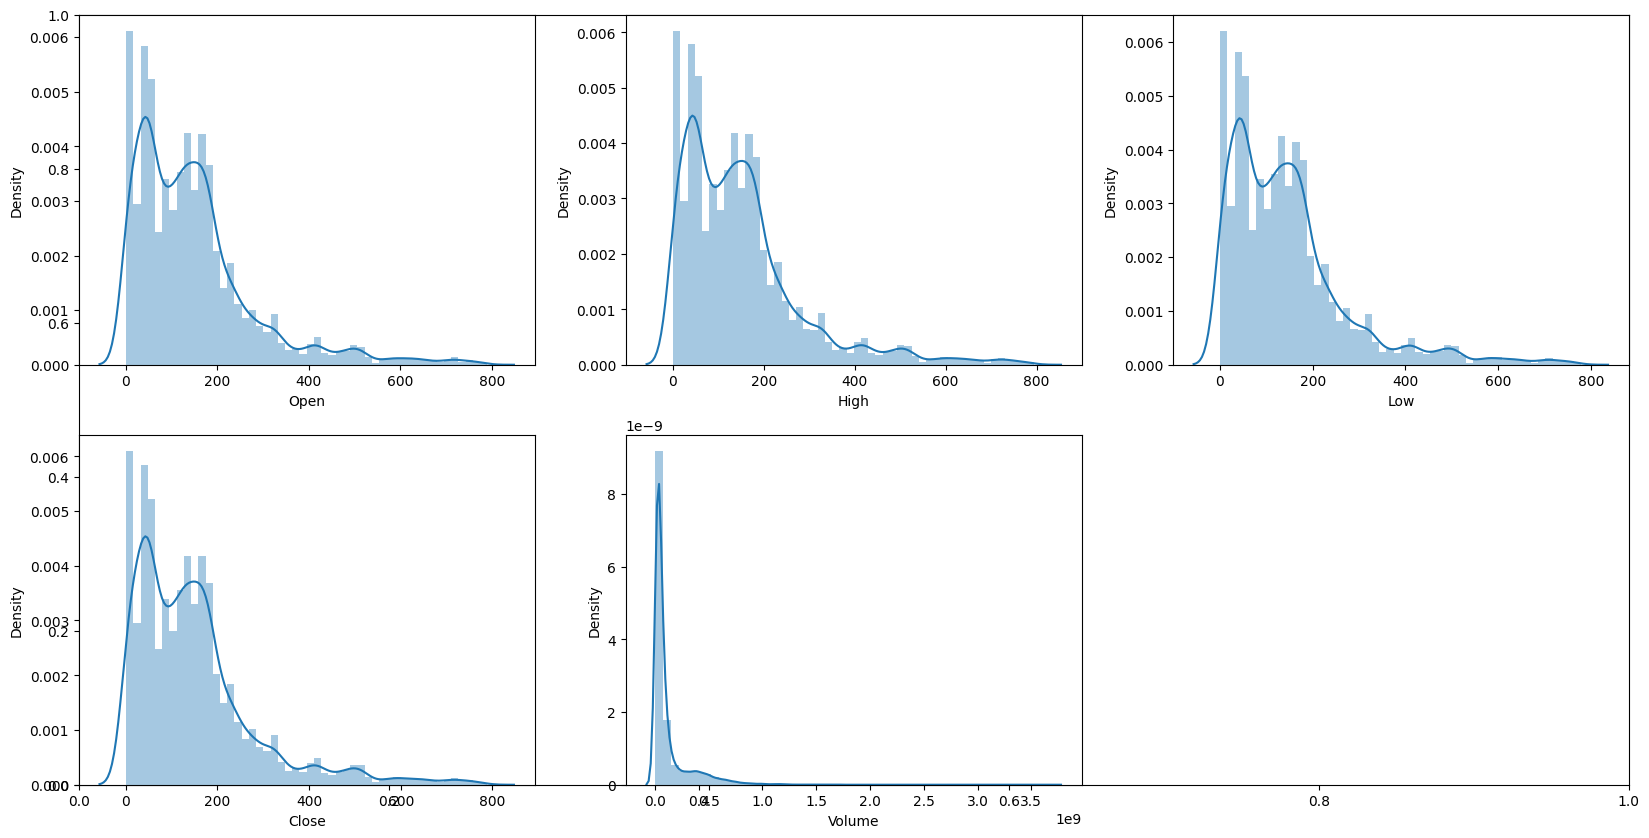

In [25]:
features =["Open","High","Low","Close","Volume"]
plt.subplots(figsize=(20,10))

for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.distplot(df[col])
plt.show()

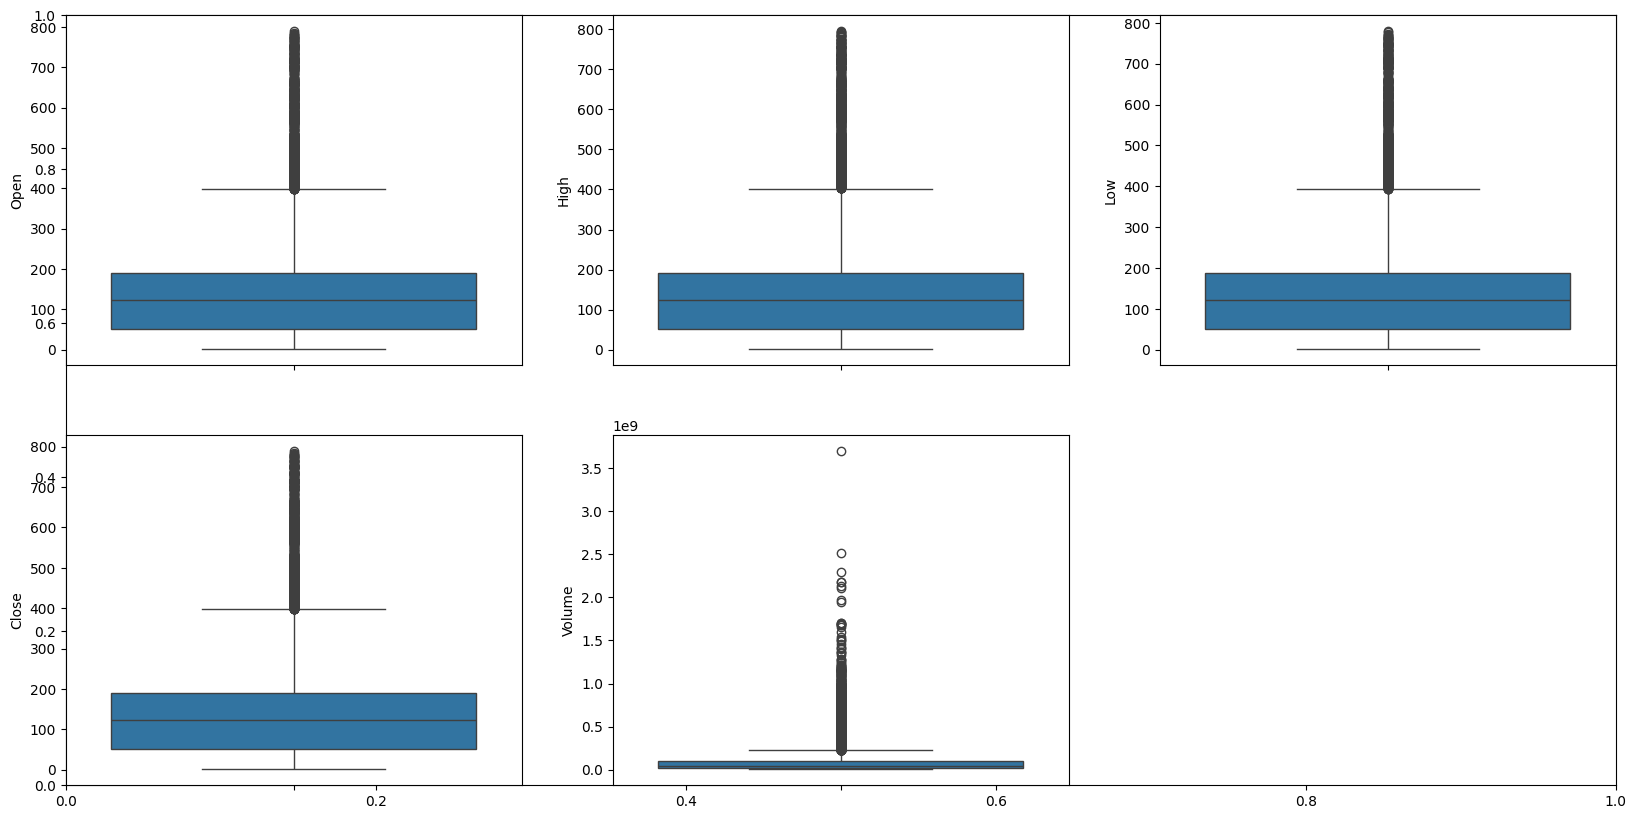

In [26]:
plt.subplots(figsize=(20,10))
for i, col in enumerate(features):
  plt.subplot(2,3,i+1)
  sb.boxplot(df[col])
plt.show()

In [30]:
#performance model
# df["Date"] is already a datetime object, so use .dt accessor
df['day'] = df["Date"].dt.day.astype('int')
df['month'] = df["Date"].dt.month.astype('int')
df["year"] = df["Date"].dt.year.astype('int')
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,...,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,day,month,year
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,...,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145,23,2,2016
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,...,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000,23,2,2016
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,...,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696,23,2,2016
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,...,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588,23,2,2016
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,...,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239,23,2,2016


In [32]:
df["is_quarter_end"] = np.where(df["month"]%2==0,1,0)
df.head()

,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,...,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,day,month,year,is_quarter_end
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,...,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145,23,2,2016,1
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,...,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000,23,2,2016,1
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,...,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696,23,2,2016,1
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,...,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588,23,2,2016,1
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,...,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239,23,2,2016,1


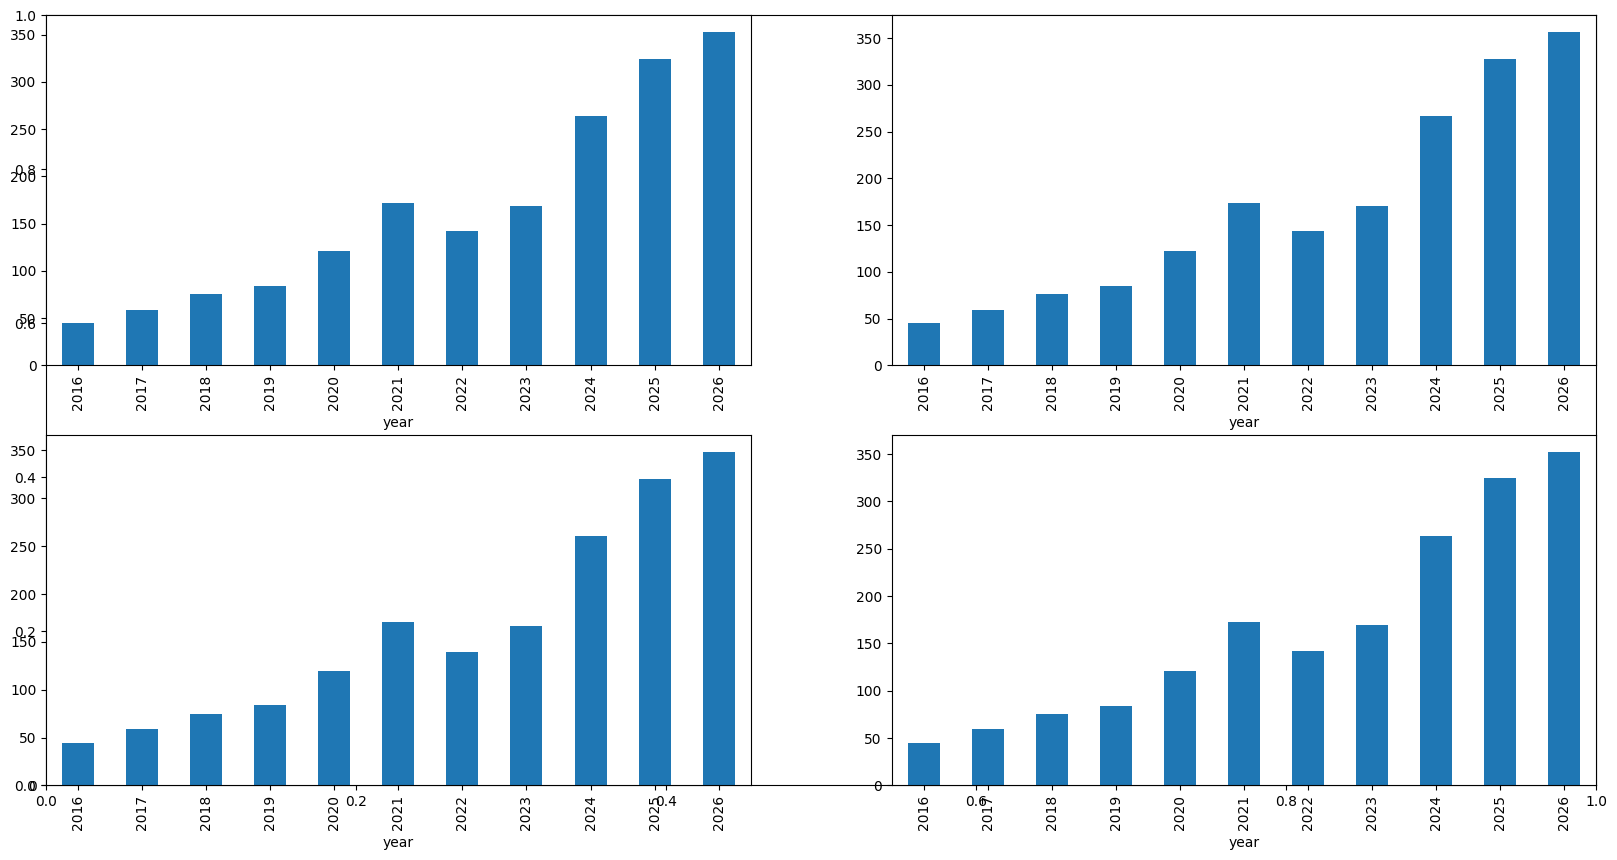

In [34]:
data_grouped = df.drop(['Date', 'Ticker'], axis=1).groupby('year').mean()
plt.subplots(figsize=(20,10))

for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [36]:
df.drop(['Date', 'Ticker'], axis=1).groupby('is_quarter_end').mean()

,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,day,month,year
is_quarter_end,,,,,,,,,,,,,,,,,,,,
0,147.358418,149.016956,145.611296,147.377787,1.208803e+08,147.002219,146.307590,146.746167,145.966894,55.918233,0.779273,0.798326,155.675974,137.029930,0.001771,0.018852,147.545412,15.875801,5.99359,2020.629006
1,148.582482,150.271574,146.903170,148.622890,1.163655e+08,148.261966,147.186407,147.883415,146.890164,55.455347,0.993251,0.978297,156.420972,138.115967,0.000898,0.018221,148.708095,15.606742,7.17496,2020.547352


In [38]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

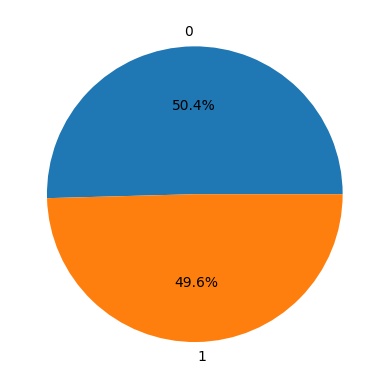

In [39]:
plt.pie(df['target'].value_counts().values,
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

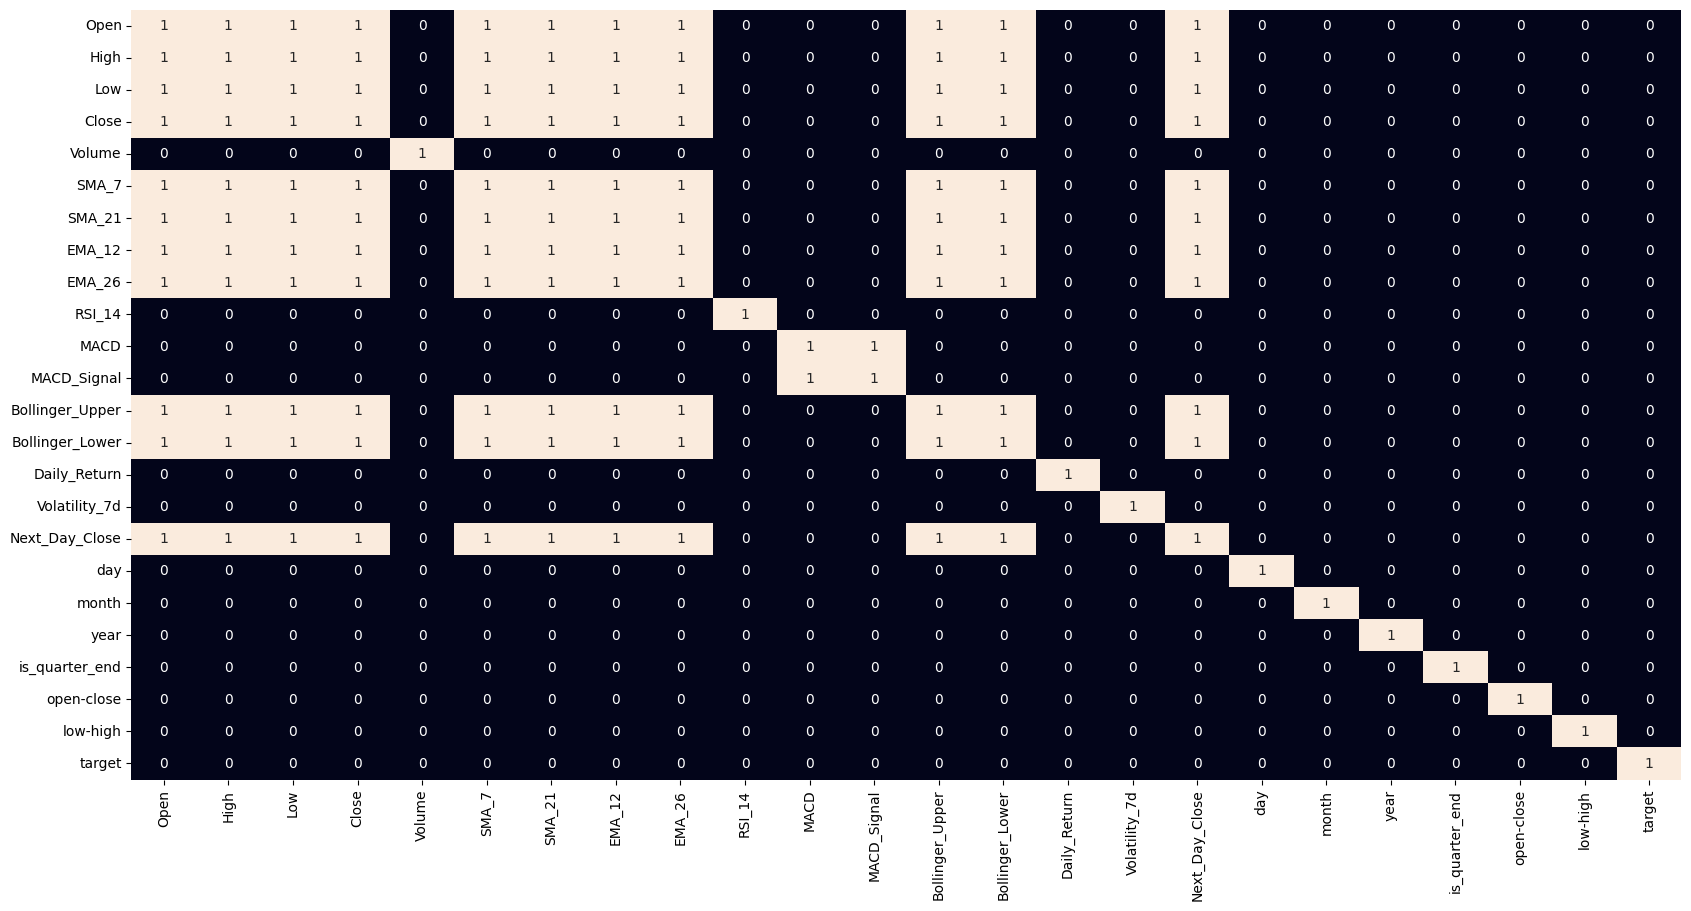

In [42]:
plt.figure(figsize=(20, 10))
sb.heatmap(df.drop(['Date', 'Ticker'], axis=1).corr() > 0.9, annot=True, cbar=False)
plt.show()

In [46]:
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

scaler = StandardScaler()
features = scaler.fit_transform(features)

X_train, X_valid, Y_train, Y_valid = train_test_split(
    features, target, test_size=0.1, random_state=2025)
print(X_train.shape, X_valid.shape)

(13467, 3) (1497, 3)


In [47]:
models = [LogisticRegression(), SVC(
  kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(
    Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(
    Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.7517071750273152
Validation Accuracy :  0.7569625225418251

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.7519333124705321
Validation Accuracy :  0.7548752834467121

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Traini

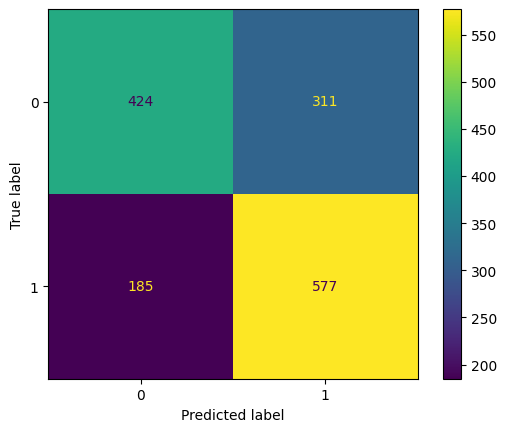

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(models[0],X_valid,Y_valid)
plt.show()